# Figure 7. The mechanism of Figure 1 on two structures from sport and movement

Code for Figure 7 of *Exploration under risk sustains functional capacity in hub-dependent networks when failure propagation is contained* (C. Park, rsif-2026-0461, revision R1).

The notebook has four parts.

1. **The model.** One realisation of the network-agent dynamics of the Model section, written in C and called from Python.
2. **The two structures and their populations.** The observed positional passing network of professional football (ref. [1]) run as a league of 20 teams, and a coordinative structure of the lower limb run as a squad of 20 athletes. Failure spreads within a team or an athlete, and imitation draws its role model from the whole league or squad.
3. **The values quoted in the text.** Main text, Supplementary Table 5 and Supplementary Note 5.
4. **The figure**, drawn in the cell with `plt.show()`.

With `RUN_SIMULATIONS = False`, the default, the notebook reads the archived output `league_data.npz` and `limb_data.npz` from its own folder and needs no compiler. With `RUN_SIMULATIONS = True` it compiles the C code and reruns both populations, which takes about 30 minutes for the league and 5 minutes for the squad on two cores at T = 1,000,000 steps and R = 10 realisations. A rerun reproduces the archived means within their 95% intervals. Agreement to the last digit depends on the compiler and the processor.

It needs Python 3.9 or later with numpy, scipy, networkx and matplotlib. Reruns also need a C compiler, gcc or clang, which on Windows means MinGW-w64 gcc or WSL.

In [1]:
%matplotlib inline
import os, sys, ctypes, platform, shutil, subprocess, time
from concurrent.futures import ThreadPoolExecutor
import numpy as np
import networkx as nx
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.patches import Circle, FancyArrowPatch, Wedge, Polygon
from matplotlib.colors import to_rgb
from matplotlib.path import Path
from scipy import stats

RUN_SIMULATIONS = False                  # True: compile the C model and rerun the league and the squad
T_STEPS, R_REAL = 1_000_000, 10          # simulation length and realisations per condition
N_THREADS = max(1, (os.cpu_count() or 2) - 1)
LEAGUE_FILE, LIMB_FILE = 'league_data.npz', 'limb_data.npz'   # archived output, read when RUN_SIMULATIONS is False
print('Python', sys.version.split()[0], '| numpy', np.__version__, '| networkx', nx.__version__,
      '| matplotlib', mpl.__version__, '| threads', N_THREADS)

Python 3.11.15 | numpy 2.4.4 | networkx 3.6.1 | matplotlib 3.10.9 | threads 1


## 1. The model

One realisation follows the step order of the Supplementary Methods. Failure potential originates at each node with probability p_n and propagates along each link with probability p_l, from failed nodes only under the conditional rule (regime 0) and from every node under the unrestricted rule (regime 1). Failed agents recover after one step, failure is realised with the protection level of equation (3), capacity is updated by equation (1), each strategy component is imitated with the Fermi probability of equation (5) from a role model drawn from the whole population, and each component is explored with a normal increment of standard deviation σ_e. The function returns stationary means over the final half of the run, for the population and for every agent. This is the source that produced the archived output. The next cell writes it to `hc7.c` and compiles it when a compiler is found.

In [2]:
HC7_C = r"""
/* Hidden-cost model, one realisation, for Figure 7 (sport application).
   Same step order and rules as the Python model in core/ and simulation/:
   origination, propagation, recovery (rt = 1), failure realisation with the current protection level,
   capacity update, imitation of S0 then S1 with the Fermi rule on c_m (synchronous copy from a snapshot,
   role model drawn from the whole population), exploration of S0 then S1.
   Additions: regime flag (0 conditional: only failed nodes transmit; 1 unrestricted: every node transmits)
   and per-agent stationary means.
   Build: gcc -O3 -march=native -shared -fPIC -o libhc7.so hc7.c -lm                                   */
#include <stdint.h>
#include <stdlib.h>
#include <math.h>
#include <string.h>

static inline uint64_t rotl(const uint64_t x, int k) { return (x << k) | (x >> (64 - k)); }
typedef struct { uint64_t s[4]; int has_g; double g; } rng_t;
static uint64_t splitmix64(uint64_t *x) {
    uint64_t z = (*x += 0x9E3779B97F4A7C15ULL);
    z = (z ^ (z >> 30)) * 0xBF58476D1CE4E5B9ULL;
    z = (z ^ (z >> 27)) * 0x94D049BB133111EBULL;
    return z ^ (z >> 31);
}
static void rng_seed(rng_t *r, uint64_t seed) {
    uint64_t x = seed;
    for (int i = 0; i < 4; i++) r->s[i] = splitmix64(&x);
    r->has_g = 0; r->g = 0.0;
}
static inline uint64_t rng_next(rng_t *r) {
    uint64_t *s = r->s;
    const uint64_t result = rotl(s[0] + s[3], 23) + s[0];
    const uint64_t t = s[1] << 17;
    s[2] ^= s[0]; s[3] ^= s[1]; s[1] ^= s[2]; s[0] ^= s[3]; s[2] ^= t; s[3] = rotl(s[3], 45);
    return result;
}
static inline double rng_u(rng_t *r) { return (rng_next(r) >> 11) * 0x1.0p-53; }
static inline int rng_int(rng_t *r, int n) { return (int)(rng_u(r) * n); }
static inline double rng_normal(rng_t *r) {
    if (r->has_g) { r->has_g = 0; return r->g; }
    double u1 = rng_u(r), u2 = rng_u(r);
    while (u1 <= 1e-300) u1 = rng_u(r);
    double rad = sqrt(-2.0 * log(u1)), th = 6.283185307179586 * u2;
    r->g = rad * sin(th); r->has_g = 1;
    return rad * cos(th);
}

/* out[0..5]: stationary means of c_m, f, f_p, f_p*c (cost), SD of f_p across agents, p_p
   agent_out (may be NULL): 4 x n per-agent stationary means of f_p, failure, c_m, p_p          */
int run_realisation(int n, const int *src, const int *dst, int n_edges_dir,
                    const double *cent, double pe, double pr, long T,
                    double pn, double pl, double pmax, double cp, double cin, double fm,
                    double memory, double s, double sigma, uint64_t seed, int regime,
                    double *out, double *agent_out)
{
    rng_t R; rng_seed(&R, seed);
    double *Capital = malloc(n * sizeof(double)), *Cm = malloc(n * sizeof(double));
    double *S0 = calloc(n, sizeof(double)), *S1 = calloc(n, sizeof(double));
    double *fp = malloc(n * sizeof(double)), *pp = malloc(n * sizeof(double));
    double *tmp = malloc(n * sizeof(double));
    double *afp = calloc(n, sizeof(double)), *af = calloc(n, sizeof(double));
    double *acm = calloc(n, sizeof(double)), *app = calloc(n, sizeof(double));
    unsigned char *fail = calloc(n, 1), *pot = malloc(n);
    int *im = malloc(n * sizeof(int));
    for (int i = 0; i < n; i++) { Capital[i] = cin; Cm[i] = memory; }
    long T_half = T / 2;
    double acc[6] = {0, 0, 0, 0, 0, 0};
    long nacc = 0;

    for (long t = 0; t < T; t++) {
        for (int i = 0; i < n; i++) pot[i] = (rng_u(&R) < pn);                 /* 1 origination */
        for (int e = 0; e < n_edges_dir; e++)                                    /* 2 propagation */
            if ((regime == 1 || fail[src[e]]) && rng_u(&R) <= pl) pot[dst[e]] = 1;
        memset(fail, 0, n);                                                      /* 3 recovery, rt = 1 */
        double sfp = 0, sfp2 = 0, spp = 0;
        for (int i = 0; i < n; i++) {                                            /* 4 realisation */
            double v = S0[i] + S1[i] * cent[i];
            if (v < 0) v = 0; if (v > 1.0 - fm) v = 1.0 - fm;
            fp[i] = v;
            double fc = v * Capital[i]; if (fc < 1e-12) fc = 1e-12;
            pp[i] = pmax / (1.0 + cp / fc);
            spp += pp[i]; sfp += v; sfp2 += v * v;
            if (pot[i] && rng_u(&R) > pp[i]) { fail[i] = 1; Capital[i] = 0.0; }
        }
        double scm = 0, sf = 0, scost = 0;
        for (int i = 0; i < n; i++) {                                            /* 5 capacity update */
            scost += fp[i] * Capital[i];
            Capital[i] = cin + (1.0 - fm - fp[i]) * Capital[i];
            Cm[i] = memory * Capital[i] + (1.0 - memory) * Cm[i];
            scm += Cm[i]; sf += fail[i];
        }
        if (t >= T_half) {
            double mfp = sfp / n, var = sfp2 / n - mfp * mfp; if (var < 0) var = 0;
            acc[0] += scm / n; acc[1] += sf / n; acc[2] += mfp; acc[3] += scost / n;
            acc[4] += sqrt(var); acc[5] += spp / n; nacc++;
            if (agent_out) for (int i = 0; i < n; i++) { afp[i] += fp[i]; af[i] += fail[i]; acm[i] += Cm[i]; app[i] += pp[i]; }
        }
        double *strats[2] = {S0, S1};                                            /* 6, 7 imitation */
        for (int k = 0; k < 2; k++) {
            double *st = strats[k]; int nim = 0;
            for (int i = 0; i < n; i++) if (rng_u(&R) <= pr) im[nim++] = i;
            if (!nim) continue;
            memcpy(tmp, st, n * sizeof(double));
            for (int j = 0; j < nim; j++) {
                int i = im[j], rr = rng_int(&R, n);
                while (rr == i) rr = rng_int(&R, n);
                double x = -s * (Cm[rr] - Cm[i]); if (x > 500) x = 500; if (x < -500) x = -500;
                double pi = 1.0 / (1.0 + exp(x));
                if (rng_u(&R) <= pi) st[i] = tmp[rr];
            }
        }
        for (int i = 0; i < n; i++) if (rng_u(&R) <= pe) S0[i] += sigma * rng_normal(&R);   /* 8, 9 exploration */
        for (int i = 0; i < n; i++) if (rng_u(&R) <= pe) S1[i] += sigma * rng_normal(&R);
    }
    for (int k = 0; k < 6; k++) out[k] = acc[k] / nacc;
    if (agent_out) for (int i = 0; i < n; i++) {
        agent_out[i] = afp[i] / nacc; agent_out[n + i] = af[i] / nacc;
        agent_out[2 * n + i] = acm[i] / nacc; agent_out[3 * n + i] = app[i] / nacc;
    }
    free(Capital); free(Cm); free(S0); free(S1); free(fp); free(pp); free(tmp); free(fail); free(pot); free(im);
    free(afp); free(af); free(acm); free(app);
    return 0;
}
"""


def build_library(src=HC7_C, stem='hc7'):
    """Write the C source next to the notebook and compile it into a shared library; returns its path or None."""
    with open(stem + '.c', 'w') as fh:
        fh.write(src)
    system = platform.system()
    lib = {'Windows': stem + '.dll', 'Darwin': 'lib' + stem + '.dylib'}.get(system, 'lib' + stem + '.so')
    for cc in ('gcc', 'cc', 'clang'):
        if shutil.which(cc):
            cmd = [cc, '-O3', '-shared', '-o', lib, stem + '.c'] + ([] if system == 'Windows' else ['-fPIC', '-lm'])
            done = subprocess.run(cmd, capture_output=True, text=True)
            if done.returncode == 0:
                print('compiled with', ' '.join(cmd))
                return os.path.abspath(lib)
            print(cc, 'failed:', done.stderr[:400])
    print('No C compiler found. The archived output can still be analysed and plotted.')
    return None


LIB_PATH = build_library() if RUN_SIMULATIONS else None

In [3]:
PARAMS = dict(pn=0.1, pl=0.3, pmax=1.0, cp=0.05, cin=1.0, fm=0.1, memory=0.99, s=10.0, sigma=0.001)
KEYS = ['cm', 'f', 'fp', 'pc', 'div', 'pp']   # capacity c_m, failure f, protection f_p, cost f_p*c, SD of f_p, p_p
_LIBS = {}


def library(path):
    """Load the compiled model once. The C function keeps no global state, and ctypes releases the GIL during
    the call, so realisations run in parallel threads."""
    if path not in _LIBS:
        lib = ctypes.CDLL(path)
        dp, ip = ctypes.POINTER(ctypes.c_double), ctypes.POINTER(ctypes.c_int)
        lib.run_realisation.argtypes = [ctypes.c_int, ip, ip, ctypes.c_int, dp, ctypes.c_double, ctypes.c_double,
                                        ctypes.c_long, ctypes.c_double, ctypes.c_double, ctypes.c_double,
                                        ctypes.c_double, ctypes.c_double, ctypes.c_double, ctypes.c_double,
                                        ctypes.c_double, ctypes.c_double, ctypes.c_uint64, ctypes.c_int, dp, dp]
        lib.run_realisation.restype = ctypes.c_int
        _LIBS[path] = lib
    return _LIBS[path]


def prepare(G, cent=None):
    """Network arrays for the C code: node count, both directions of every link, eigenvector centrality."""
    n = G.number_of_nodes()
    if cent is None:
        ec = nx.eigenvector_centrality_numpy(G)
        cent = [ec[i] for i in range(n)]
    cent = np.ascontiguousarray(cent, dtype=np.float64)
    src = np.ascontiguousarray([u for u, v in G.edges()] + [v for u, v in G.edges()], dtype=np.int32)
    dst = np.ascontiguousarray([v for u, v in G.edges()] + [u for u, v in G.edges()], dtype=np.int32)
    return n, src, dst, cent


def run(net, pe, pr, T, seed, regime=0, agents=False, **kw):
    """One realisation; regime 0 conditional, 1 unrestricted. Returns the stationary means of KEYS and, with
    agents=True, the per-agent means of f_p, failure, c_m and p_p."""
    n, src, dst, cent = net
    p = dict(PARAMS); p.update(kw)
    out = np.zeros(6); ag = np.zeros(4 * n) if agents else None
    dp, ip = ctypes.POINTER(ctypes.c_double), ctypes.POINTER(ctypes.c_int)
    library(LIB_PATH).run_realisation(
        n, src.ctypes.data_as(ip), dst.ctypes.data_as(ip), len(src), cent.ctypes.data_as(dp), pe, pr, T,
        p['pn'], p['pl'], p['pmax'], p['cp'], p['cin'], p['fm'], p['memory'], p['s'], p['sigma'], seed, regime,
        out.ctypes.data_as(dp), ag.ctypes.data_as(dp) if agents else None)
    res = dict(zip(KEYS, out))
    if agents:
        a = ag.reshape(4, n)
        res.update(fp_agent=a[0], f_agent=a[1], cm_agent=a[2], pp_agent=a[3])
    return res

## 2. The two structures and their populations

**Team.** The positional passing network of professional football from FIFA World Cup 2014 match records, ref. [1], Table 2, with eleven positions and 21 links between positions that exchange passes.

**Lower limb.** The hip, knee and ankle joints and eleven muscle groups as nodes, each muscle group linked to every joint it crosses, 14 nodes and 14 links. The groups follow standard anatomy, and the links are not measured coupling.

Each structure is copied 20 times with no links between the copies. Every agent keeps the eigenvector centrality of its node in the single structure, the leading eigenvector scaled to unit length, so the protection heuristic of equation (2) sees the same centrality in every copy. Conditions and seeds are those of the archived runs.

In [4]:
# team: the observed positional passing network, ref. [1]
EDGES = [('DM','OM'),('DM','LCD'),('DM','RCD'),('DM','LD'),('DM','RD'),('DM','LM'),('DM','RM'),('RM','RF'),('LM','LF'),
         ('LCD','LD'),('RCD','RD'),('LCD','GK'),('RCD','GK'),('OM','LF'),('RF','LF'),('OM','RF'),('OM','LM'),('OM','RM'),
         ('LCD','RCD'),('LD','LM'),('RD','RM')]
POS = ['GK','LCD','RCD','LD','RD','DM','LM','RM','OM','LF','RF']
_ix = {p: i for i, p in enumerate(POS)}
team = nx.Graph(); team.add_nodes_from(range(11)); team.add_edges_from((_ix[a], _ix[b]) for a, b in EDGES)

# lower limb: the joints crossed by each muscle group
CROSS = {'GMX': ['HIP'], 'GMD': ['HIP'], 'ILP': ['HIP'], 'ADD': ['HIP'], 'REF': ['HIP', 'KNEE'],
         'HAM': ['HIP', 'KNEE'], 'VAS': ['KNEE'], 'GAS': ['KNEE', 'ANKLE'], 'SOL': ['ANKLE'], 'TIA': ['ANKLE'],
         'PER': ['ANKLE']}
NODES = ['HIP', 'KNEE', 'ANKLE'] + list(CROSS)
NAMES = {'HIP': 'hip joint', 'KNEE': 'knee joint', 'ANKLE': 'ankle joint', 'GMX': 'gluteus maximus',
         'GMD': 'gluteus medius', 'ILP': 'iliopsoas', 'ADD': 'adductors', 'REF': 'rectus femoris',
         'HAM': 'hamstrings', 'VAS': 'vasti', 'GAS': 'gastrocnemius', 'SOL': 'soleus', 'TIA': 'tibialis anterior',
         'PER': 'peronei'}
_jx = {m: i for i, m in enumerate(NODES)}
LINKS = sorted(tuple(sorted((_jx[m], _jx[j]))) for m, js in CROSS.items() for j in js)
limb = nx.Graph(); limb.add_nodes_from(range(len(NODES))); limb.add_edges_from(LINKS)

for name, g in (('team', team), ('lower limb', limb)):
    k = np.array([d for _, d in g.degree()])
    print(f'{name}: {g.number_of_nodes()} nodes, {g.number_of_edges()} links, mean degree {k.mean():.2f}, '
          f'CV(k) = {k.std() / k.mean():.3f}, triangles {sum(nx.triangles(g).values()) // 3}')

K = 20
PR = [round(0.1 * i, 1) for i in range(1, 10)]
LEAGUE_CONDS = [('cond', pe, pr) for pe in (0.1, 0.9) for pr in PR] + [('unr', pe, 0.1) for pe in (0.1, 0.9)]
LIMB_CONDS = [('cond', 0.1, 0.1), ('cond', 0.9, 0.1), ('unr', 0.1, 0.1), ('unr', 0.9, 0.1)]


def simulate(single, conds, seed0, T=T_STEPS, R=R_REAL, K=K):
    """K disjoint copies of one structure. Failure stays within a copy, imitation runs across all copies, and every
    copy takes the centrality of the single structure. Per-node values are averaged over the K copies."""
    n1 = single.number_of_nodes()
    ec = nx.eigenvector_centrality_numpy(single)
    cent1 = np.array([ec[i] for i in range(n1)])
    G = nx.Graph(); G.add_nodes_from(range(n1 * K))
    for k in range(K):
        G.add_edges_from((n1 * k + u, n1 * k + v) for u, v in single.edges())
    net = prepare(G, cent=np.tile(cent1, K))
    out = dict(T=T, R=R, K=K, cent=cent1, pr_values=np.array(sorted({c[2] for c in conds})),
               degree=np.array([single.degree(i) for i in range(n1)]))
    t_all = time.time()
    for ci, (reg, pe, pr) in enumerate(conds):
        def one(r):
            res = run(net, pe, pr, T, seed0 + 1000 * ci + r, regime=(1 if reg == 'unr' else 0), agents=True)
            pos = {q: res[q + '_agent'].reshape(K, n1).mean(axis=0) for q in ('fp', 'f', 'cm', 'pp')}
            return {**{q: res[q] for q in KEYS}, **{'pos_' + q: v for q, v in pos.items()}}
        with ThreadPoolExecutor(N_THREADS) as ex:
            runs = list(ex.map(one, range(R)))
        for q in runs[0]:
            out[f'{reg}_pe{pe}_pr{pr}_{q}'] = np.array([x[q] for x in runs])
        cm, f = out[f'{reg}_pe{pe}_pr{pr}_cm'], out[f'{reg}_pe{pe}_pr{pr}_f']
        print(f'[{ci + 1}/{len(conds)}] {reg} pe={pe} pr={pr}: cm {cm.mean():.4f}, f {f.mean():.4f} '
              f'({(time.time() - t_all) / 60:.1f} min)', flush=True)
    return out


if RUN_SIMULATIONS:
    assert LIB_PATH, 'the C model is not compiled'
    LEAGUE_DATA = simulate(team, LEAGUE_CONDS, seed0=70_000)
    LEAGUE_DATA['positions'] = np.array(POS)
    SQUAD_DATA = simulate(limb, LIMB_CONDS, seed0=90_000)
    SQUAD_DATA.update(nodes=np.array(NODES), names=np.array([NAMES[m] for m in NODES]), edges=np.array(LINKS))
else:
    LEAGUE_DATA = dict(np.load(LEAGUE_FILE, allow_pickle=True))
    SQUAD_DATA = dict(np.load(LIMB_FILE, allow_pickle=True))
print('league:', int(LEAGUE_DATA['K']), 'teams, T =', int(LEAGUE_DATA['T']), ', R =', int(LEAGUE_DATA['R']))
print('squad: ', int(SQUAD_DATA['K']), 'athletes, T =', int(SQUAD_DATA['T']), ', R =', int(SQUAD_DATA['R']))

team: 11 nodes, 21 links, mean degree 3.82, CV(k) = 0.332, triangles 11
lower limb: 14 nodes, 14 links, mean degree 2.00, CV(k) = 0.756, triangles 0
league: 20 teams, T = 1000000 , R = 10
squad:  20 athletes, T = 1000000 , R = 10


## 3. The values quoted in the text

Relative differences between the hub and the least central node are computed within each realisation and reported as mean ± 95% t interval across realisations. Slopes on eigenvector centrality are fitted within each realisation across the nodes, as for Supplementary Fig. 7. Equation (4) is evaluated with the expected number of failed neighbours, the sum of their simulated failure frequencies. Exploration differences carry bootstrap 95% intervals from 10,000 resamples of realisations.

In [5]:
PN, PL, S_SEL = PARAMS['pn'], PARAMS['pl'], PARAMS['s']
tq = lambda R: stats.t.ppf(0.975, R - 1)


def ci(x):
    x = np.asarray(x, float)
    return x.mean(), tq(len(x)) * x.std(ddof=1) / np.sqrt(len(x))


def p4(m):
    return 1 - (1 - PN) * (1 - PL) ** m


structures = {'team (league)': (LEAGUE_DATA, [str(p) for p in LEAGUE_DATA['positions']], team, 'DM', 'GK'),
              'limb (squad)': (SQUAD_DATA, [str(p) for p in SQUAD_DATA['nodes']], limb, 'HIP', 'SOL')}
for label, (D, names, g, hub, low) in structures.items():
    ih, il = names.index(hub), names.index(low)
    print(f'--- {label}: hub {hub}, least central {low}')
    for cond in ('cond_pe0.1_pr0.1', 'unr_pe0.1_pr0.1'):
        for q, what in (('fp', 'protection f_p'), ('f', 'failure f'), ('cm', 'capacity c_m')):
            X = D[f'{cond}_pos_{q}']
            m, h = ci(100 * (X[:, ih] - X[:, il]) / X[:, il])
            rule = 'conditional ' if cond.startswith('cond') else 'unrestricted'
            print(f'  {rule} {what:15s} hub against least central {m:+6.1f} ± {h:.1f} %')
    c, u = D['cond_pe0.1_pr0.1_cm'].mean(), D['unr_pe0.1_pr0.1_cm'].mean()
    print(f'  capacity, unrestricted against conditional: {100 * (u - c) / c:+.1f} %; failure '
          f'{D["cond_pe0.1_pr0.1_f"].mean():.3f} -> {D["unr_pe0.1_pr0.1_f"].mean():.3f}')
    cent = D['cent']
    for pe in ('0.1', '0.9'):
        sl = []
        for q in ('f', 'cm', 'fp'):
            s = [np.polyfit(cent, y, 1)[0] for y in D[f'cond_pe{pe}_pr0.1_pos_{q}']]
            m, h = ci(s)
            sl.append(f'{q} {m:+.4f} ± {h:.4f}')
        print(f'  slopes on centrality at pe = {pe}: ' + ', '.join(sl))
    f_node = D['cond_pe0.1_pr0.1_pos_f'].mean(0)
    for node in ([hub, 'ANKLE', 'KNEE'] if hub == 'HIP' else [hub]):
        i = names.index(node)
        m = sum(f_node[j] for j in g[i])
        print(f'  equation (4) at {node}: k = {g.degree(i)}, C = {cent[i]:.3f}, conditional {p4(m):.3f}, '
              f'unrestricted {p4(g.degree(i)):.3f}')
    gap = D['cond_pe0.1_pr0.1_pos_cm'].mean(0)[il] - D['cond_pe0.1_pr0.1_pos_cm'].mean(0)[ih]
    print(f'  capacity gap {gap:.3f}: hub copies least central with p = {1 / (1 + np.exp(-S_SEL * gap)):.4f}, '
          f'reverse {1 / (1 + np.exp(S_SEL * gap)):.4f}')

rng = np.random.default_rng(20260924)


def boot(a, b, n=10_000):
    d = b[rng.integers(0, len(b), (n, len(b)))].mean(1) - a[rng.integers(0, len(a), (n, len(a)))].mean(1)
    return b.mean() - a.mean(), np.percentile(d, 2.5), np.percentile(d, 97.5)


print('--- exploration, pe = 0.9 against 0.1 (bootstrap 95% intervals)')
for label, D, prs in (('league', LEAGUE_DATA, LEAGUE_DATA['pr_values']), ('squad', SQUAD_DATA, [0.1])):
    for pr in prs:
        a, b = D[f'cond_pe0.1_pr{pr}_cm'], D[f'cond_pe0.9_pr{pr}_cm']
        fa, fb = D[f'cond_pe0.1_pr{pr}_f'], D[f'cond_pe0.9_pr{pr}_f']
        d, lo, hi = boot(a, b); df, flo, fhi = boot(fa, fb)
        print(f'  {label} pr {pr}: capacity {d:+.3f} [{lo:+.3f}, {hi:+.3f}] ({100 * d / a.mean():+.2f} %), '
              f'failure {df:+.4f} [{flo:+.4f}, {fhi:+.4f}]')
    d, lo, hi = boot(D['unr_pe0.1_pr0.1_cm'], D['unr_pe0.9_pr0.1_cm'])
    print(f'  {label} unrestricted, pr 0.1: capacity {d:+.3f} [{lo:+.3f}, {hi:+.3f}] '
          f'({100 * d / D["unr_pe0.1_pr0.1_cm"].mean():+.2f} %)')

--- team (league): hub DM, least central GK
  conditional  protection f_p  hub against least central  +67.0 ± 5.9 %
  conditional  failure f       hub against least central  +44.0 ± 3.8 %
  conditional  capacity c_m    hub against least central  -10.6 ± 0.5 %
  unrestricted protection f_p  hub against least central  +39.8 ± 10.2 %
  unrestricted failure f       hub against least central  +58.5 ± 10.6 %
  unrestricted capacity c_m    hub against least central  -21.0 ± 0.8 %
  capacity, unrestricted against conditional: -36.5 %; failure 0.083 -> 0.170
  slopes on centrality at pe = 0.1: f +0.0870 ± 0.0065, cm -1.7800 ± 0.0884, fp +0.0210 ± 0.0015
  slopes on centrality at pe = 0.9: f +0.0766 ± 0.0053, cm -1.7962 ± 0.0673, fp +0.0246 ± 0.0014
  equation (4) at DM: k = 7, C = 0.499, conditional 0.269, unrestricted 0.926
  capacity gap 0.646: hub copies least central with p = 0.9984, reverse 0.0016
--- limb (squad): hub HIP, least central SOL
  conditional  protection f_p  hub against least

### The single team, run with the same code

Supplementary Note 5 compares the league with one team run alone, 40 realisations at each exploration level with the protocol of Supplementary Fig. 7. With `RUN_SIMULATIONS = False` the cell reads the archived check `single_team_check.npz`, and if `sfig7_data.npz` from the repository is in the folder it also compares the failure frequency with Supplementary Fig. 7.

In [6]:
SINGLE_FILE = 'single_team_check.npz'
if RUN_SIMULATIONS:
    net1 = prepare(team)
    SINGLE = {}
    for pe, seed0 in ((0.1, 50_000), (0.9, 60_000)):
        with ThreadPoolExecutor(N_THREADS) as ex:
            runs = list(ex.map(lambda r: run(net1, pe, 0.1, T_STEPS, seed0 + r, agents=True), range(40)))
        SINGLE.update({f'pe{pe}_f': np.array([x['f'] for x in runs]), f'pe{pe}_fp': np.array([x['fp'] for x in runs]),
                       f'pe{pe}_cm': np.array([x['cm'] for x in runs]),
                       f'pe{pe}_fp_agent': np.array([x['fp_agent'] for x in runs])})
else:
    SINGLE = dict(np.load(SINGLE_FILE)) if os.path.exists(SINGLE_FILE) else None

if SINGLE is None:
    print('single_team_check.npz not found; set RUN_SIMULATIONS = True to run the check')
else:
    ec = nx.eigenvector_centrality_numpy(team)
    cent_team = np.array([ec[i] for i in range(11)])
    for pe in ('0.1', '0.9'):
        f, fp = SINGLE[f'pe{pe}_f'], SINGLE[f'pe{pe}_fp']
        m, h = ci(f)
        sm, sh = ci([np.polyfit(cent_team, y, 1)[0] for y in SINGLE[f'pe{pe}_fp_agent']])
        print(f'single team, pe = {pe}: failure {m:.3f} ± {h:.3f}; slope of effective protection on centrality '
              f'{sm:+.3f} ± {sh:.3f}; realisations with no protection left {int((fp < 1e-4).sum())} of {len(fp)}')
    if os.path.exists('sfig7_data.npz'):
        ref = np.load('sfig7_data.npz')['pe0.1_f']
        m, h = ci(ref)
        p = stats.ttest_ind(SINGLE['pe0.1_f'], ref, equal_var=False).pvalue
        print(f'Supplementary Fig. 7, pe = 0.1: failure {m:.3f} ± {h:.3f}; Welch t test p = {p:.2f}')
    for label, D in (('league', LEAGUE_DATA), ('squad', SQUAD_DATA)):
        low = min(D[k].min() for k in D if k.endswith('_fp') and '_pos_' not in k)
        print(f'{label}: lowest population effective protection in any realisation {low:.4f}')

single team, pe = 0.1: failure 0.132 ± 0.023; slope of effective protection on centrality -0.066 ± 0.039; realisations with no protection left 1 of 40
single team, pe = 0.9: failure 0.121 ± 0.008; slope of effective protection on centrality -0.097 ± 0.054; realisations with no protection left 0 of 40
Supplementary Fig. 7, pe = 0.1: failure 0.166 ± 0.098; Welch t test p = 0.47
league: lowest population effective protection in any realisation 0.0089
squad: lowest population effective protection in any realisation 0.0115


In [7]:
# Supplementary Table 5: per-node means at pe = pr = 0.1 under conditional propagation, rows by centrality
def table5(D, names, g, label=lambda p: p):
    cent = D['cent']
    val = {q: D['cond_pe0.1_pr0.1_pos_' + q].mean(0) for q in ('f', 'fp', 'pp', 'cm')}
    order = sorted(range(len(names)), key=lambda i: (-round(cent[i], 6), i))
    rows = [(label(names[i]), ', '.join(label(names[j]) for j in sorted(g[i], key=lambda j: (-round(cent[j], 6), j))),
             f'{g.degree(i)}', f'{cent[i]:.3f}', f'{val["f"][i]:.3f}', f'{val["fp"][i]:.4f}', f'{val["pp"][i]:.3f}',
             f'{val["cm"][i]:.2f}') for i in order]
    head = ('node', 'linked to', 'k', 'C', 'f', 'fp', 'pp', 'cm')
    w = [max(len(r[c]) for r in rows + [head]) for c in range(len(head))]
    for r in [head] + rows:
        print('  '.join(x.ljust(w[c]) if c < 2 else x.rjust(w[c]) for c, x in enumerate(r)))


table5(LEAGUE_DATA, [str(p) for p in LEAGUE_DATA['positions']], team)
print()
table5(SQUAD_DATA, [str(p) for p in SQUAD_DATA['nodes']], limb, label=lambda p: NAMES[p].replace(' joint', ''))

node  linked to                     k      C      f      fp     pp    cm
DM    OM, LM, RM, LCD, RCD, LD, RD  7  0.499  0.103  0.0192  0.610  5.46
OM    DM, LM, RM, LF, RF            5  0.375  0.091  0.0165  0.591  5.70
LM    DM, OM, LD, LF                4  0.322  0.084  0.0154  0.582  5.82
RM    DM, OM, RD, RF                4  0.322  0.084  0.0154  0.582  5.82
LCD   DM, RCD, LD, GK               4  0.278  0.085  0.0145  0.568  5.81
RCD   DM, LCD, RD, GK               4  0.278  0.085  0.0145  0.568  5.81
LD    DM, LM, LCD                   3  0.261  0.077  0.0141  0.569  5.96
RD    DM, RM, RCD                   3  0.261  0.077  0.0141  0.569  5.96
LF    OM, LM, RF                    3  0.217  0.078  0.0132  0.553  5.97
RF    OM, RM, LF                    3  0.217  0.078  0.0132  0.553  5.98
GK    LCD, RCD                      2  0.132  0.072  0.0115  0.521  6.10

node               linked to                                                                          k      C      f      

## 4. The figure

The drawing code of the submitted Figure 7. Left is the league and right the squad. Middle top is equation (4) against degree under both rules, and middle bottom is equation (5) and the flat chance of exploration, with the capacity gap between the least central node and the hub of each structure. Each node is the agent of Figure 1 with the simulated means of its node, the dark blue rim for the protection level p_p from 0 to 1, the amber ring for memorised functional capacity c_m from 4 to 7 and the orange arc for the protection strategy f_p from 0 to 0.02. Node size follows degree and the colour strength inside each node follows eigenvector centrality. The last cell draws the figure and shows it with `plt.show()`.

In [8]:
# Figure 7 (R1): the mechanism of Figure 1 on two sport structures, in the layout and the agent language of
# Figure 1.
# Left:   the observed football passing network [1], eleven positions in formation (attacking upward); a league of 20
#         such teams.
# Right:  a lower-limb coordinative structure: the hip, knee and ankle joints and eleven muscle groups as nodes, a link
#         where a muscle group crosses a joint; a squad of 20 such athletes.
# Middle, top:    equation (4) at the real degrees, both rules, one conditional line per structure.
# Middle, bottom: the imitation rule of equation (5) and flat exploration, with the capacity gap between the hub and
#                 the least central node of each structure.
# Both populations: failure within a team or an athlete, imitation across the population, conditional propagation,
# p_e = 0.1, p_r = 0.1, R = 10, T = 1,000,000, stationary means over the final half (league_data.npz, limb_data.npz).
# Each node is drawn as the agent of Figure 1 and carries the simulated values of its position: the yellow ring is the
# capacity c_m (scale 4 to 7), the dark ring inside the blue band the protection level p_p (0 to 1), the orange arc on
# the rim the protection strategy f_p (0 to 0.02). As in Figure 4, size shows degree k and colour shows centrality:
# agent size follows degree (key, upper left, beside the degree plot), and the colour strength of the inside of each
# agent follows eigenvector centrality on one scale for both structures (colour bar, lower right), so hubs stand out as
# in a preferential-attachment network. Outlines, orange arcs and links stay at full strength. Links are the grey beams of Figure 1, with width by pass weight (team)
# or uniform (limb). As in Figure 1, one neighbour of each hub is shown failed (capacity emptied, red bolt) and passes
# a loss to the hub along their beam with probability p_l; the hub is i and the failed neighbour j. Behind the limb is
# a pale shade of the leg (trunk, thigh, shank and foot) through the hip, knee and ankle nodes, drawn schematically.
# Size follows Figures 1 to 6, 6.69 in (170 mm) wide.
def pick_font(candidates=('Arial', 'Liberation Sans', 'Helvetica', 'DejaVu Sans')):
    """The first of the candidate sans-serif fonts that is installed (Arial, as in Figures 1 to 6, where present)."""
    for c in candidates:
        try:
            font_manager.findfont(font_manager.FontProperties(family=c), fallback_to_default=False)
            return c
        except ValueError:
            pass
    return 'DejaVu Sans'


FONT = pick_font()
mpl.rcParams.update({
    'font.family': 'sans-serif', 'font.sans-serif': [FONT, 'DejaVu Sans'],
    'font.weight': 'normal', 'axes.labelweight': 'normal',
    'pdf.fonttype': 42, 'ps.fonttype': 42,
    'mathtext.fontset': 'custom', 'mathtext.default': 'it',
    'mathtext.rm': FONT, 'mathtext.it': FONT + ':italic', 'mathtext.bf': FONT, 'mathtext.sf': FONT,
    'mathtext.cal': FONT, 'mathtext.tt': FONT,
    'figure.dpi': 200,                   # display resolution in the notebook; the figure is 170 mm wide
})
print('font:', FONT)

# colours of Figure 1, plus one identity colour per structure (team green, limb brown) for hubs and connectors
BLUE_L, BLUE_D = '#C5D9F1', '#1F497D'
YEL_L, YEL_D = '#FFF6DA', '#FFC000'
ORANGE, GREY, RISK = '#E36C0A', '#C9C9C9', '#C00000'
BONE = '#EEE6D8'                                        # pale shade of the leg
BLUE, RED = '#4393C3', '#D6604D'
INK, SOFT = '#1A1A1A', '#4A4A4A'
TEAM_C, LIMB_C = '#4F7A57', '#9B6F3F'
FS_TITLE, FS_LABEL, FS_TINY, FS_NODE = 7.8, 6.8, 6.2, 5.8
PN, PL, S_SEL = 0.1, 0.3, 10.0
# DOT is the conditional line of Figure 1 (team); DASHDOT (limb) has twice its period, so where the two conditional
# lines coincide the limb's dashes and dots fall inside the team's dashes and the pair reads as one clean line
SOLID, DOT, DASHDOT = '-', (0, (2.4, 1.6)), (0, (2.4, 2.4, 0.8, 2.4))
LINK_LS = (0, (1.5, 1.3))
KEY = 'cond_pe0.1_pr0.1_pos_'
YLIM = (-0.80, 0.74)                                   # shared by both structures, so both are drawn to one scale
FW, FH = 4016 / 600, 2.0                               # the width of Figures 1 to 6
PLOT_YLIM = (-0.10, 1.24)                              # middle plots: room for the axis labels and the end markers
L_IN = 0.60                                            # height at which the limb connector enters the top plot
CM_SCALE = (4.0, 7.0)                                  # capacity shown by the yellow ring, from empty to full
FP_SCALE = 0.02                                        # protection strategy shown by the orange arc, full arc
S_MIN, S_GAMMA = 0.22, 1.5                             # colour strength: faintest agent, and how fast it rises
K_MAX = 7                                              # largest degree in either structure (DM)
SCALE = 0.825 * FH / (YLIM[1] - YLIM[0])               # inches per data unit of the network panels

# ------------------------------------------------------------------ the two structures
def load(z, names_key):
    """Per-node means of one structure from its simulation output (dict or npz)."""
    d = dict(names=[str(p) for p in z[names_key]], cent=np.asarray(z['cent'], float))
    for q in ('cm', 'f', 'fp', 'pp'):
        d[q] = np.asarray(z[KEY + q], float).mean(0)
    return d, z


TEAM, _ = load(LEAGUE_DATA, 'positions')
TEAM['edges'] = {('DM', 'OM'): 0.8, ('DM', 'LCD'): 0.8, ('DM', 'RCD'): 0.8, ('DM', 'LD'): 0.1, ('DM', 'RD'): 0.1,
                 ('DM', 'LM'): 0.06, ('DM', 'RM'): 0.06, ('RM', 'RF'): 0.08, ('LM', 'LF'): 0.05,
                 ('LCD', 'LD'): 0.05, ('RCD', 'RD'): 0.05, ('LCD', 'GK'): 0.025, ('RCD', 'GK'): 0.025,
                 ('OM', 'LF'): 0.2, ('RF', 'LF'): 0.2, ('OM', 'RF'): 0.2, ('OM', 'LM'): 0.2, ('OM', 'RM'): 0.2,
                 ('LCD', 'RCD'): 0.2, ('LD', 'LM'): 0.2, ('RD', 'RM'): 0.2}          # pass weights, ref. [1]
TEAM['xy'] = {'GK': (0.00, -0.63), 'LCD': (-0.15, -0.44), 'RCD': (0.15, -0.44), 'LD': (-0.34, -0.31),
              'RD': (0.34, -0.31), 'DM': (0.00, -0.17), 'LM': (-0.31, 0.15), 'RM': (0.31, 0.15),
              'OM': (0.00, 0.24), 'LF': (-0.16, 0.47), 'RF': (0.16, 0.47)}          # attacking upward
TEAM['label'] = {p: p for p in TEAM['names']}
TEAM['label_at'] = {p: ('left' if p in ('LCD', 'LD', 'LM', 'LF') else 'right') for p in TEAM['names']}
TEAM['label_at']['OM'] = ('right', 0.010, 0.055)                                # clear of the OM-RM and OM-RF links
TEAM.update(hub='DM', edge_node='GK', failed='OM', j_at=(-0.028, 0.012), pl_off=0.060, centre=(0.0, -0.08), rad=0.12,
            xlim=(-0.55, 0.55), italic=set(),
            link_lw=lambda w: 0.9 + 3.3 * np.sqrt(w / 0.8))

STRETCH = 1.25                                                                   # limb drawn wider than life


def sx(x):
    return 0.62 + STRETCH * (x - 0.62)


LIMB, _zl = load(SQUAD_DATA, 'nodes')
LIMB['edges'] = {(LIMB['names'][a], LIMB['names'][b]): 1.0 for a, b in _zl['edges']}     # muscle group - joint
LIMB['xy'] = {k: (sx(x), y) for k, (x, y) in {
    'HIP': (0.66, 0.38), 'KNEE': (0.60, -0.14), 'ANKLE': (0.60, -0.62),
    'ILP': (0.46, 0.47), 'GMD': (0.73, 0.60), 'GMX': (0.93, 0.40), 'ADD': (0.52, 0.23), 'REF': (0.39, 0.09),
    'HAM': (0.83, 0.09), 'VAS': (0.43, -0.15), 'GAS': (0.77, -0.30), 'SOL': (0.74, -0.52), 'TIA': (0.46, -0.40),
    'PER': (0.48, -0.555)}.items()}                                                # side view, front to the left
LIMB['label'] = {'HIP': 'hip', 'KNEE': 'knee', 'ANKLE': 'ankle', 'GMX': 'glut max', 'GMD': 'glut med',
                 'ILP': 'iliopsoas', 'ADD': 'adductors', 'REF': 'rect fem', 'HAM': 'hamstrings', 'VAS': 'vasti',
                 'GAS': 'gastroc', 'SOL': 'soleus', 'TIA': 'tib ant', 'PER': 'peronei'}
LIMB['label_at'] = {'HIP': 'below', 'KNEE': 'right', 'ANKLE': ('right', 0.0, -0.035), 'ILP': 'left', 'GMD': 'right',
                    'GMX': 'below', 'ADD': 'left', 'REF': 'left', 'HAM': 'right', 'VAS': 'left', 'GAS': 'right',
                    'SOL': 'right', 'TIA': 'left', 'PER': 'left'}
LIMB.update(hub='HIP', edge_node='SOL', failed='GMX', j_at=(0.050, 0.085), pl_off=0.070, pl_at=(0.90, 0.475), centre=(0.62, 0.0), rad=0.12,
            xlim=(-0.02, 1.36), italic={'HIP', 'KNEE', 'ANKLE'},
            link_lw=lambda w: 1.7)

for S in (TEAM, LIMB):
    S['ix'] = {p: i for i, p in enumerate(S['names'])}
    nb = {p: [] for p in S['names']}
    for a, b in S['edges']:
        nb[a].append(b); nb[b].append(a)
    S['deg'] = {p: len(nb[p]) for p in S['names']}
    S['m_cond'] = {p: sum(S['f'][S['ix'][q]] for q in nb[p]) for p in S['names']}   # expected failed neighbours
    S['f_bar'] = S['f'].mean()
    S['gap'] = S['cm'][S['ix'][S['edge_node']]] - S['cm'][S['ix'][S['hub']]]           # periphery minus hub

CENT_REF = max(TEAM['cent'].max(), LIMB['cent'].max())


def node_r(k):
    """Agent radius (data units of the network panels) from degree, one scale for both structures."""
    return 0.046 + 0.045 * (k - 1) / (K_MAX - 1)


def strength(c):
    """Colour strength of an agent from its eigenvector centrality, one scale for both structures."""
    return min(1.0, S_MIN + (1 - S_MIN) * (c / CENT_REF) ** S_GAMMA)


def tint(colour, s):
    """A colour of Figure 1 at strength s: s = 1 is the colour itself, lower values fade it toward white."""
    return tuple(1 - s * (1 - np.asarray(to_rgb(colour))))


def bend(p0, p1, centre, rad):
    """Curvature for a beam drawn from p0 to p1, bent away from the centre of its network. The sign flips with the
    direction, so a beam and an arrow along it follow the same arc whichever end they start from."""
    p0, p1 = np.asarray(p0, float), np.asarray(p1, float)
    d, m = p1 - p0, 0.5 * (p0 + p1) - np.asarray(centre)
    side = d[1] * m[0] - d[0] * m[1]
    if abs(side) < 1e-9:
        side = d[0] + d[1]
    return rad if side > 0 else -rad


def p4(m):
    return 1 - (1 - PN) * (1 - PL) ** m


def fermi(x):
    return 1 / (1 + np.exp(-S_SEL * x))

font: Liberation Sans


In [9]:
# ------------------------------------------------------------------ house style of Figure 1
def style(ax):
    for s in ('left', 'right'):
        ax.spines[s].set_visible(False)
    for s in ('top', 'bottom'):
        ax.spines[s].set_linewidth(0.7); ax.spines[s].set_color('#5A5A5A')
    ax.tick_params(labelsize=FS_TINY, length=2.2, width=0.6, pad=1.6, direction='in',
                   left=False, right=False, labelleft=False, labelright=False)
    ax.grid(alpha=0.15, linewidth=0.5)
    ax.set_axisbelow(True)


def centre_axis(ax, yvals, xc, on_tick=False):
    """One y axis up the middle of the plot, as in Figure 1. Labels sit just above their ticks (Figure 1), or level
    with them (on_tick) where a curve passes just above a tick."""
    x0, x1 = ax.get_xlim(); y0, y1 = ax.get_ylim()
    d = 0.010 * (x1 - x0)
    ax.axvline(xc, color='#5A5A5A', lw=0.7, zorder=8)
    for v in yvals:
        ax.plot([xc - d, xc + d], [v, v], color='#5A5A5A', lw=0.6, zorder=9, solid_capstyle='butt')
        if on_tick:
            ax.text(xc - 1.9 * d, v, f'{v:g}', ha='right', va='center_baseline', fontsize=FS_TINY, color=INK,
                    zorder=10)
        else:
            ax.text(xc - 1.7 * d, v + 0.015 * (y1 - y0), f'{v:g}', ha='right', va='bottom', fontsize=FS_TINY,
                    color=INK, zorder=10)


def agent(ax, c, r, capital, strategy, protection, z=5, focal=False, s=1.0, failed=False):
    """The agent of Figure 1, drawn at marker size: capacity is the yellow ring inside the pale disc, the protection
    level the dark ring inside the blue band, the protection strategy the orange arc on the rim. Only the inside takes
    the colour strength s; the outline and the orange arc stay at full strength. A failed agent has its capacity
    emptied and carries the red bolt, as in Figure 1."""
    cx, cy = c
    ry = 0.70 * r
    ax.add_patch(Circle((cx, cy), r, facecolor=tint(BLUE_L, s), edgecolor='none', zorder=z))
    ax.add_patch(Wedge((cx, cy), r, 0, 360, width=protection * (r - ry) + 0.012 * r, facecolor=tint(BLUE_D, s),
                       edgecolor='none', zorder=z + 0.1))
    ax.add_patch(Circle((cx, cy), ry, facecolor=tint(YEL_L, s), edgecolor=tint(BLUE_D, s), lw=0.35, zorder=z + 0.2))
    ax.add_patch(Wedge((cx, cy), ry, 0, 360, width=(0.04 if failed else capital) * ry, facecolor=tint(YEL_D, s),
                       edgecolor='none', zorder=z + 0.3))
    th = np.deg2rad(np.linspace(200, 200 + 300 * strategy, 160))
    rr = 1.13 * r + 0.006
    ax.plot(cx + rr * np.cos(th), cy + rr * np.sin(th), color='white', lw=1.7, solid_capstyle='round', zorder=z + 0.4)
    ax.plot(cx + rr * np.cos(th), cy + rr * np.sin(th), color=ORANGE, lw=0.95, solid_capstyle='round',
            zorder=z + 0.5)
    ax.add_patch(Circle((cx, cy), r, fill=False, edgecolor=BLUE_D, lw=0.9 if focal else 0.55, zorder=z + 0.35))
    if failed:
        bolt = np.array([[0.00, 0.95], [-0.34, 0.05], [-0.05, 0.05], [-0.22, -0.95], [0.34, 0.15], [0.03, 0.15]])
        ax.add_patch(Polygon(np.asarray(c) + bolt * r * 0.88, closed=True, facecolor=RISK, edgecolor='white', lw=0.4,
                             zorder=z + 0.6))
    return rr


def beam_link(ax, p0, p1, lw, centre, rad, z=2):
    """A grey beam as in Figure 1, bent slightly away from the centre of its network so that neighbouring beams stay
    apart."""
    r = bend(p0, p1, centre, rad)
    ax.add_patch(FancyArrowPatch(tuple(p0), tuple(p1), arrowstyle='-', connectionstyle=f'arc3,rad={r}',
                                 linewidth=lw, color=GREY, alpha=0.85, capstyle='butt', shrinkA=0, shrinkB=0,
                                 zorder=z))


def loss_arrow(ax, p_from, p_to, r_from, r_to, centre, rad, pl_off, pl_at=None):
    """The red loss arrow of Figure 1, along the beam from a failed agent to its neighbour, with p_l beside it on the
    outer side of the bend. r_from and r_to are the radii (data units) at which the arrow starts and stops."""
    p0, p1 = np.asarray(p_from, float), np.asarray(p_to, float)
    r = bend(p0, p1, centre, rad)
    pt = 72 * SCALE                                                             # points per data unit
    ax.add_patch(FancyArrowPatch(tuple(p0), tuple(p1), arrowstyle='-|>', mutation_scale=6.5,
                                 connectionstyle=f'arc3,rad={r}', color=RISK, linewidth=1.3,
                                 shrinkA=r_from * pt + 1.0, shrinkB=r_to * pt + 1.2, zorder=9))
    d = p1 - p0
    out = r * np.array([d[1], -d[0]])                                           # bulge of the arc at its middle
    u = out / np.hypot(*out)
    mid = 0.5 * (p0 + p1) + 0.5 * out + u * pl_off if pl_at is None else np.asarray(pl_at, float)
    ax.text(mid[0], mid[1], '$p_\\mathrm{l}$', ha='center', va='center', fontsize=FS_TINY, color=RISK, zorder=15)


def connector(ax, pts, color, r_in=0.045):
    """A connector from a structure to its value in a middle plot, along the corner points pts (figure
    fractions), with rounded corners of radius r_in (inches; one value, or one per corner), in the colour of the
    structure."""
    pts = [np.asarray(p, float) for p in pts]
    radii = np.broadcast_to(np.asarray(r_in, float), (len(pts) - 2,))
    verts, codes = [pts[0]], [Path.MOVETO]
    for a, p, b, r in zip(pts[:-2], pts[1:-1], pts[2:], radii):
        u1, u2 = (p - a), (b - p)
        u1, u2 = u1 / np.hypot(u1[0] * FW, u1[1] * FH), u2 / np.hypot(u2[0] * FW, u2[1] * FH)
        verts += [p - u1 * r, p, p + u2 * r]; codes += [Path.LINETO, Path.CURVE3, Path.CURVE3]
    verts.append(pts[-1]); codes.append(Path.LINETO)
    ax.add_patch(FancyArrowPatch(path=Path(verts, codes), arrowstyle='-|>', mutation_scale=5.5, color=color,
                                 linewidth=0.75, linestyle=LINK_LS, alpha=0.95, zorder=20, shrinkA=0, shrinkB=0))


def origin(ax, p, color, marker):
    ax.plot([p[0]], [p[1]], marker, color=color, ms=4.0 if marker == 'o' else 3.6, mec='white', mew=0.6, zorder=21)


def at(fig, target_ax, x, y):
    return tuple(fig.transFigure.inverted().transform(target_ax.transData.transform((x, y))))


def size_key(ax, xc, yb, scale, vals=(1, 4, 7)):
    """Key to agent size (degree k), drawn to the scale of the network panels. xc is the centre and yb the bottom of
    the discs, as figure fractions; scale is inches per data unit of the network panels."""
    r = [node_r(v) for v in vals]
    gap = 0.075
    w_u, h_u = 2 * sum(r) + gap * (len(r) - 1), 2 * r[-1]
    w, h = w_u * scale / FW, h_u * scale / FH
    kax = ax.inset_axes([xc - w / 2, yb, w, h])
    kax.set_xlim(0, w_u); kax.set_ylim(0, h_u); kax.axis('off')
    x = 0.0
    for v, rr in zip(vals, r):
        x += rr
        kax.add_patch(Circle((x, rr), rr, facecolor=BLUE_L, edgecolor=BLUE_D, lw=0.55, clip_on=False))
        kax.text(x, -0.035, f'{v:g}', ha='center', va='top', fontsize=FS_NODE, color=INK)
        x += rr + gap
    kax.text(w_u / 2, h_u + 0.035, 'degree $k$', ha='center', va='bottom', fontsize=FS_NODE, color=SOFT)


def strength_bar(ax, rect, c_max=0.6, ticks=(0.1, 0.3, 0.5)):
    """Colour bar for the colour strength of the inside of the agents: the protection blue above and the capacity
    yellow below, each at the strength that eigenvector centrality gives, so the bar shows the agents' own colours."""
    cax = ax.inset_axes(rect)
    c = np.linspace(0, c_max, 256)
    s = np.array([strength(v) for v in c])
    img = np.stack([np.array([tint(BLUE_D, v) for v in s]), np.array([tint(YEL_D, v) for v in s])])
    cax.imshow(img, aspect='auto', extent=(0, c_max, 0, 1), interpolation='bilinear')
    cax.axhline(0.5, color='white', lw=0.5)
    cax.set_yticks([]); cax.set_xticks(ticks); cax.set_xlim(0, c_max)
    cax.tick_params(labelsize=FS_NODE, length=1.8, width=0.5, pad=1.2)
    for sp in cax.spines.values():
        sp.set_linewidth(0.5); sp.set_color('#5A5A5A')
    cax.set_title('eigenvector centrality', fontsize=FS_NODE, color=SOFT, pad=2.0)

In [10]:
# ------------------------------------------------------------------ panels
def leg(ax):
    """Pale shade of the right leg in side view, front to the left: trunk, thigh and shank through the hip, knee and
    ankle nodes, and the foot. Wide and pale, so it reads as a background and never as a beam."""
    H, K, A = (LIMB['xy'][j] for j in ('HIP', 'KNEE', 'ANKLE'))
    trunk = (0.62, 0.66)
    heel, toe = (sx(0.662), -0.722), (sx(0.405), -0.722)
    kw = dict(color=BONE, lw=4.2, solid_capstyle='round', solid_joinstyle='round', zorder=0.3)
    ax.plot([trunk[0], H[0], K[0], A[0]], [trunk[1], H[1], K[1], A[1]], **kw)
    ax.add_patch(Polygon([heel, A, toe], closed=True, facecolor=BONE, edgecolor=BONE, lw=4.2, joinstyle='round',
                         zorder=0.3))


def network(ax, S, ring_colour, background=None):
    """The structure as a plot of the simulation. Each node is the agent of Figure 1 with the simulated capacity,
    protection level and protection strategy of that position; its size is eigenvector centrality. The hub carries a
    ring in the colour of its structure."""
    ax.axis('off'); ax.set_aspect('equal')
    ax.set_xlim(*S['xlim']); ax.set_ylim(*YLIM)
    if background:
        background(ax)
    for (a, b), w in S['edges'].items():
        beam_link(ax, S['xy'][a], S['xy'][b], S['link_lw'](w), S['centre'], S['rad'])
    lo, hi = CM_SCALE
    rings = {}
    for p in S['names']:
        i = S['ix'][p]
        x, y = S['xy'][p]
        r = node_r(S['deg'][p])
        hub = p == S['hub']
        rr = agent(ax, (x, y), r, capital=np.clip((S['cm'][i] - lo) / (hi - lo), 0, 1),
                   strategy=np.clip(S['fp'][i] / FP_SCALE, 0, 1), protection=np.clip(S['pp'][i], 0, 1), focal=hub,
                   s=strength(S['cent'][i]), failed=(p == S['failed']))
        ring = rr + 0.022 if hub else rr
        rings[p] = ring
        if hub:
            ax.add_patch(Circle((x, y), ring, fill=False, edgecolor=ring_colour, lw=1.0, zorder=4.5))
            ax.text(x, y, '$i$', ha='center', va='center', fontsize=FS_LABEL, color=INK, zorder=14)
        if p == S['failed']:
            jx, jy = S['j_at']
            ax.text(x + np.sign(jx) * rr + jx, y + jy, '$j$', ha='center', va='center', fontsize=FS_LABEL,
                    color='#3A3A3A', zorder=14)
        off = ring + 0.050
        pos = {'above': (x, y + off, 'center'), 'below': (x, y - off, 'center'),
               'left': (x - ring - 0.020, y, 'right'), 'right': (x + ring + 0.020, y, 'left')}
        where, dx, dy = S['label_at'][p] if isinstance(S['label_at'][p], tuple) else (S['label_at'][p], 0.0, 0.0)
        tx, ty, ha = pos[where]
        it = p in S['italic']
        ax.text(tx + dx, ty + dy, S['label'][p], ha=ha, va='center', fontsize=FS_NODE, zorder=16,
                color=ring_colour if it else SOFT, style='italic' if it else 'normal')
    f, h = S['failed'], S['hub']
    loss_arrow(ax, S['xy'][f], S['xy'][h], rings[f], rings[h], S['centre'], S['rad'], S['pl_off'], S.get('pl_at'))


def exposure_plot(ax):
    style(ax)
    ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False)
    k = np.linspace(0, 8, 300)
    ax.plot(k, p4(k), color=RED, lw=1.3, ls=SOLID, zorder=3)
    ax.plot(k, p4(TEAM['f_bar'] * k), color=BLUE, lw=1.2, ls=DOT, zorder=3)
    ax.plot(k, p4(LIMB['f_bar'] * k), color=BLUE, lw=1.2, ls=DASHDOT, zorder=3)
    for S, mk, ms, col in ((TEAM, 'o', 3.0, TEAM_C), (LIMB, 'D', 2.7, LIMB_C)):
        for p in S['names']:
            if p != S['hub']:
                ax.plot(S['deg'][p], p4(S['m_cond'][p]), mk, ms=ms, color=BLUE, mec='white', mew=0.4, zorder=5)
        kh = S['deg'][S['hub']]
        ax.plot(kh, p4(kh), mk, ms=ms + 0.4, color=RED, mec='white', mew=0.5, zorder=5)
        ax.plot(kh, p4(S['m_cond'][S['hub']]), mk, ms=ms + 1.0, color=col, mec='white', mew=0.6, zorder=7)
    ax.text(0.2, 1.00, 'fail anyway', fontsize=FS_TINY, color=RED, ha='left', va='center')
    ax.text(4.12, 0.50, 'fail only\nwhen failed', fontsize=FS_TINY, color=BLUE, ha='left', va='center',
            linespacing=1.05)
    ax.set_xlim(0, 8); ax.set_ylim(*PLOT_YLIM)
    ax.set_xticks([0, 4, 8]); ax.set_yticks([0, 0.5, 1])
    ax.xaxis.set_label_position('top')
    ax.set_xlabel('degree $k$', fontsize=FS_TINY, labelpad=1.2)
    centre_axis(ax, [0, 0.5, 1], 4.0, on_tick=True)


GAP_Y = {'team': 0.27, 'limb': 0.39}


def fermi_plot(ax):
    style(ax)
    dx = np.linspace(-1, 1, 400)
    ax.plot(dx, fermi(dx), color=BLUE, lw=1.3, ls=SOLID, zorder=3)
    ax.plot(dx, np.full_like(dx, 0.5), color=RED, lw=1.3, ls=DOT, zorder=3)
    ax.text(-0.96, 0.92, 'imitation,  eq. (5)', fontsize=FS_TINY, color=BLUE, ha='left', va='center')
    ax.text(-0.96, 0.66, 'exploration', fontsize=FS_TINY, color=RED, ha='left', va='center')
    # capacity gap between the hub and the least central node of each structure, and where it sets imitation;
    # each value sits just under the connector that brings it in, at the edge of the plot, which keeps the narrow
    # band between the axis label '0' and the exploration line free of text
    for S, name, mk, ms, ls, col in ((TEAM, 'team', 'o', 3.2, DOT, TEAM_C), (LIMB, 'limb', 'D', 2.9, DASHDOT, LIMB_C)):
        g, y = S['gap'], GAP_Y[name]
        ax.plot([-g, g], [y, y], color=col, lw=1.0, ls=ls, zorder=4)
        ax.plot([-g, g], [y, y], mk, ms=ms, color=col, mec='white', mew=0.5, zorder=5)
        for x in (-g, g):
            ax.plot(x, fermi(x), mk, ms=ms, color=col, mec='white', mew=0.5, zorder=6)
        xt, ha = (-0.97, 'left') if name == 'team' else (0.97, 'right')
        ax.text(xt, y - 0.045, f'{g:.2f}', fontsize=FS_TINY - 0.3, color=col, ha=ha, va='top')
    ax.set_xlim(-1, 1); ax.set_ylim(*PLOT_YLIM)
    ax.set_xticks([-1, 0, 1]); ax.set_xticklabels(['−1', '0', '1'])
    ax.set_yticks([0, 0.5, 1])
    ax.set_xlabel('$c_\\mathrm{m}(r) - c_\\mathrm{m}(i)$', fontsize=FS_TINY, labelpad=1.0)
    centre_axis(ax, [0, 0.5, 1], 0.0)


def build():
    fig = plt.figure(figsize=(FW, FH))
    ax = fig.add_axes([0, 0, 1, 1]); ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')
    Y0, H_S = 0.070, 0.825
    scale = H_S * FH / (YLIM[1] - YLIM[0])                                     # inches per data unit
    W_L = (TEAM['xlim'][1] - TEAM['xlim'][0]) * scale / FW
    W_R = (LIMB['xlim'][1] - LIMB['xlim'][0]) * scale / FW
    X_L, X_R = 0.004, 0.996 - W_R

    left = ax.inset_axes([X_L, Y0, W_L, H_S]); network(left, TEAM, TEAM_C)
    left.text(0.0, YLIM[0] + 0.045, 'attacking upwards', ha='center', va='center', fontsize=FS_NODE - 0.4,
              color='#8A8A8A', style='italic')
    right = ax.inset_axes([X_R, Y0, W_R, H_S]); network(right, LIMB, LIMB_C, background=leg)
    for xc, title, foot, col in ((X_L + W_L / 2, 'An observed team [1]', 'league of 20 teams', TEAM_C),
                                 (X_R + W_R / 2, 'A coordinative structure', 'squad of 20 athletes', LIMB_C)):
        ax.text(xc, 0.955, title, ha='center', va='center', fontsize=FS_TITLE)
        ax.text(xc, 0.030, foot, ha='center', va='center', fontsize=FS_TINY, color=col)

    XM, WM = 0.335, 0.320
    top = ax.inset_axes([XM, 0.605, WM, 0.270]); exposure_plot(top)
    ax.text(XM + 0.003, 0.585, 'chance a loss arrives,  equation (4)', ha='left', va='top', fontsize=FS_TINY,
            color='#3A3A3A')
    bot = ax.inset_axes([XM, 0.165, WM, 0.270]); fermi_plot(bot)
    ax.text(XM + WM - 0.003, 0.452, 'chance $i$ moves toward the better value', ha='right', va='bottom',
            fontsize=FS_TINY, color='#3A3A3A')

    # keys: agent size (degree) at upper left beside the degree plot, colour strength (centrality) at lower right
    xl, xr = X_L + W_L + 0.012, X_R - 0.012
    size_key(ax, 0.5 * (X_L + W_L + XM) - 0.004, 0.672, scale)
    xc_bar, w_bar = 0.5 * (XM + WM + X_R) + 0.010, 0.090        # level with the degree key, clear of the tick '1'
    strength_bar(ax, [xc_bar - w_bar / 2, 0.135, w_bar, 0.026])

    # connectors: both start at the same height and enter each plot from their own side. In the top plot the team
    # runs level between the two captions and rises onto its hub from below; the limb enters from the right between
    # the curves and drops onto its hub from above, so the two never cross each other or a curve
    y_o = 0.518
    kt, kl = TEAM['deg']['DM'], LIMB['deg']['HIP']
    th, lh = at(fig, top, kt, p4(TEAM['m_cond']['DM'])), at(fig, top, kl, p4(LIMB['m_cond']['HIP']))
    l_in = at(fig, top, 0, L_IN)[1]
    tg = at(fig, bot, -TEAM['gap'], GAP_Y['team']); lg = at(fig, bot, LIMB['gap'], GAP_Y['limb'])
    xv_l, xv_r = xl + 0.022, xr - 0.022
    connector(ax, [(xl, y_o), (th[0], y_o), (th[0], th[1] - 0.019)], TEAM_C)
    connector(ax, [(xl, y_o), (xv_l, y_o), (xv_l, tg[1]), (tg[0] - 0.008, tg[1])], TEAM_C)
    connector(ax, [(xr, y_o), (xv_r, y_o), (xv_r, l_in), (lh[0], l_in), (lh[0], lh[1] + 0.017)], LIMB_C)
    connector(ax, [(xr, y_o), (xv_r, y_o), (xv_r, lg[1]), (lg[0] + 0.008, lg[1])], LIMB_C)
    origin(ax, (xl, y_o), TEAM_C, 'o'); origin(ax, (xr, y_o), LIMB_C, 'D')
    return fig

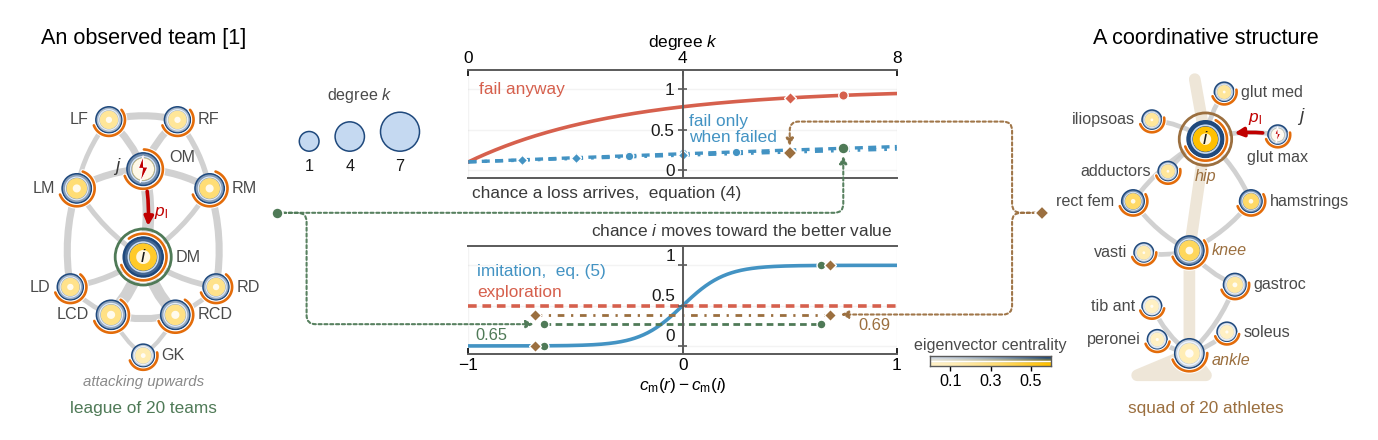

In [11]:
fig = build()
plt.show()